## **16. 특징 선택**

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# 타임스탬프 파싱 함수

def parser(x):
    return datetime.strptime(x, '%Y-%m-%d %H:%M:%S')


In [3]:
from pathlib import Path
import pandas as pd

path = Path(r'C:\data')
file_name = 'AirQualityUCI_refined.csv'

df = pd.read_csv(
    path / file_name,
    index_col=[0],
    parse_dates=[0],
    date_parser=parser,
    dtype='float32'
)

df.head()

C:\Users\toyu8\AppData\Local\Temp\ipykernel_21972\385238087.py:7: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(


,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH,AH,C6H6(GT)
Datetime,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,1046.0,166.0,1056.0,113.0,1692.0,1268.0,48.900002,0.7578,11.9
2004-03-10 19:00:00,2.0,1292.0,955.0,103.0,1174.0,92.0,1559.0,972.0,47.700001,0.7255,9.4
2004-03-10 20:00:00,2.2,1402.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,54.000000,0.7502,9.0
2004-03-10 21:00:00,2.2,1376.0,948.0,172.0,1092.0,122.0,1584.0,1203.0,60.000000,0.7867,9.2
2004-03-10 22:00:00,1.6,1272.0,836.0,131.0,1205.0,116.0,1490.0,1110.0,59.599998,0.7888,6.5


In [4]:
# # 시각화 설정 옵션 (qt5 설치된 환경에서만 실행)
# %matplotlib qt5
# %config InlineBackend.figure_format = 'svg'

# plt.rcParams['figure.figsize'] = [12, 5]
# plt.rcParams['font.size'] = 13
# plt.ion()

In [5]:
# [+] 전체 변수에 대한 결측치 처리 (선형 보간)
df.interpolate(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         9357 non-null   float32
 1   PT08.S1(CO)    9357 non-null   float32
 2   PT08.S2(NMHC)  9357 non-null   float32
 3   NOx(GT)        9357 non-null   float32
 4   PT08.S3(NOx)   9357 non-null   float32
 5   NO2(GT)        9357 non-null   float32
 6   PT08.S4(NO2)   9357 non-null   float32
 7   PT08.S5(O3)    9357 non-null   float32
 8   RH             9357 non-null   float32
 9   AH             9357 non-null   float32
 10  C6H6(GT)       9357 non-null   float32
dtypes: float32(11)
memory usage: 475.2 KB


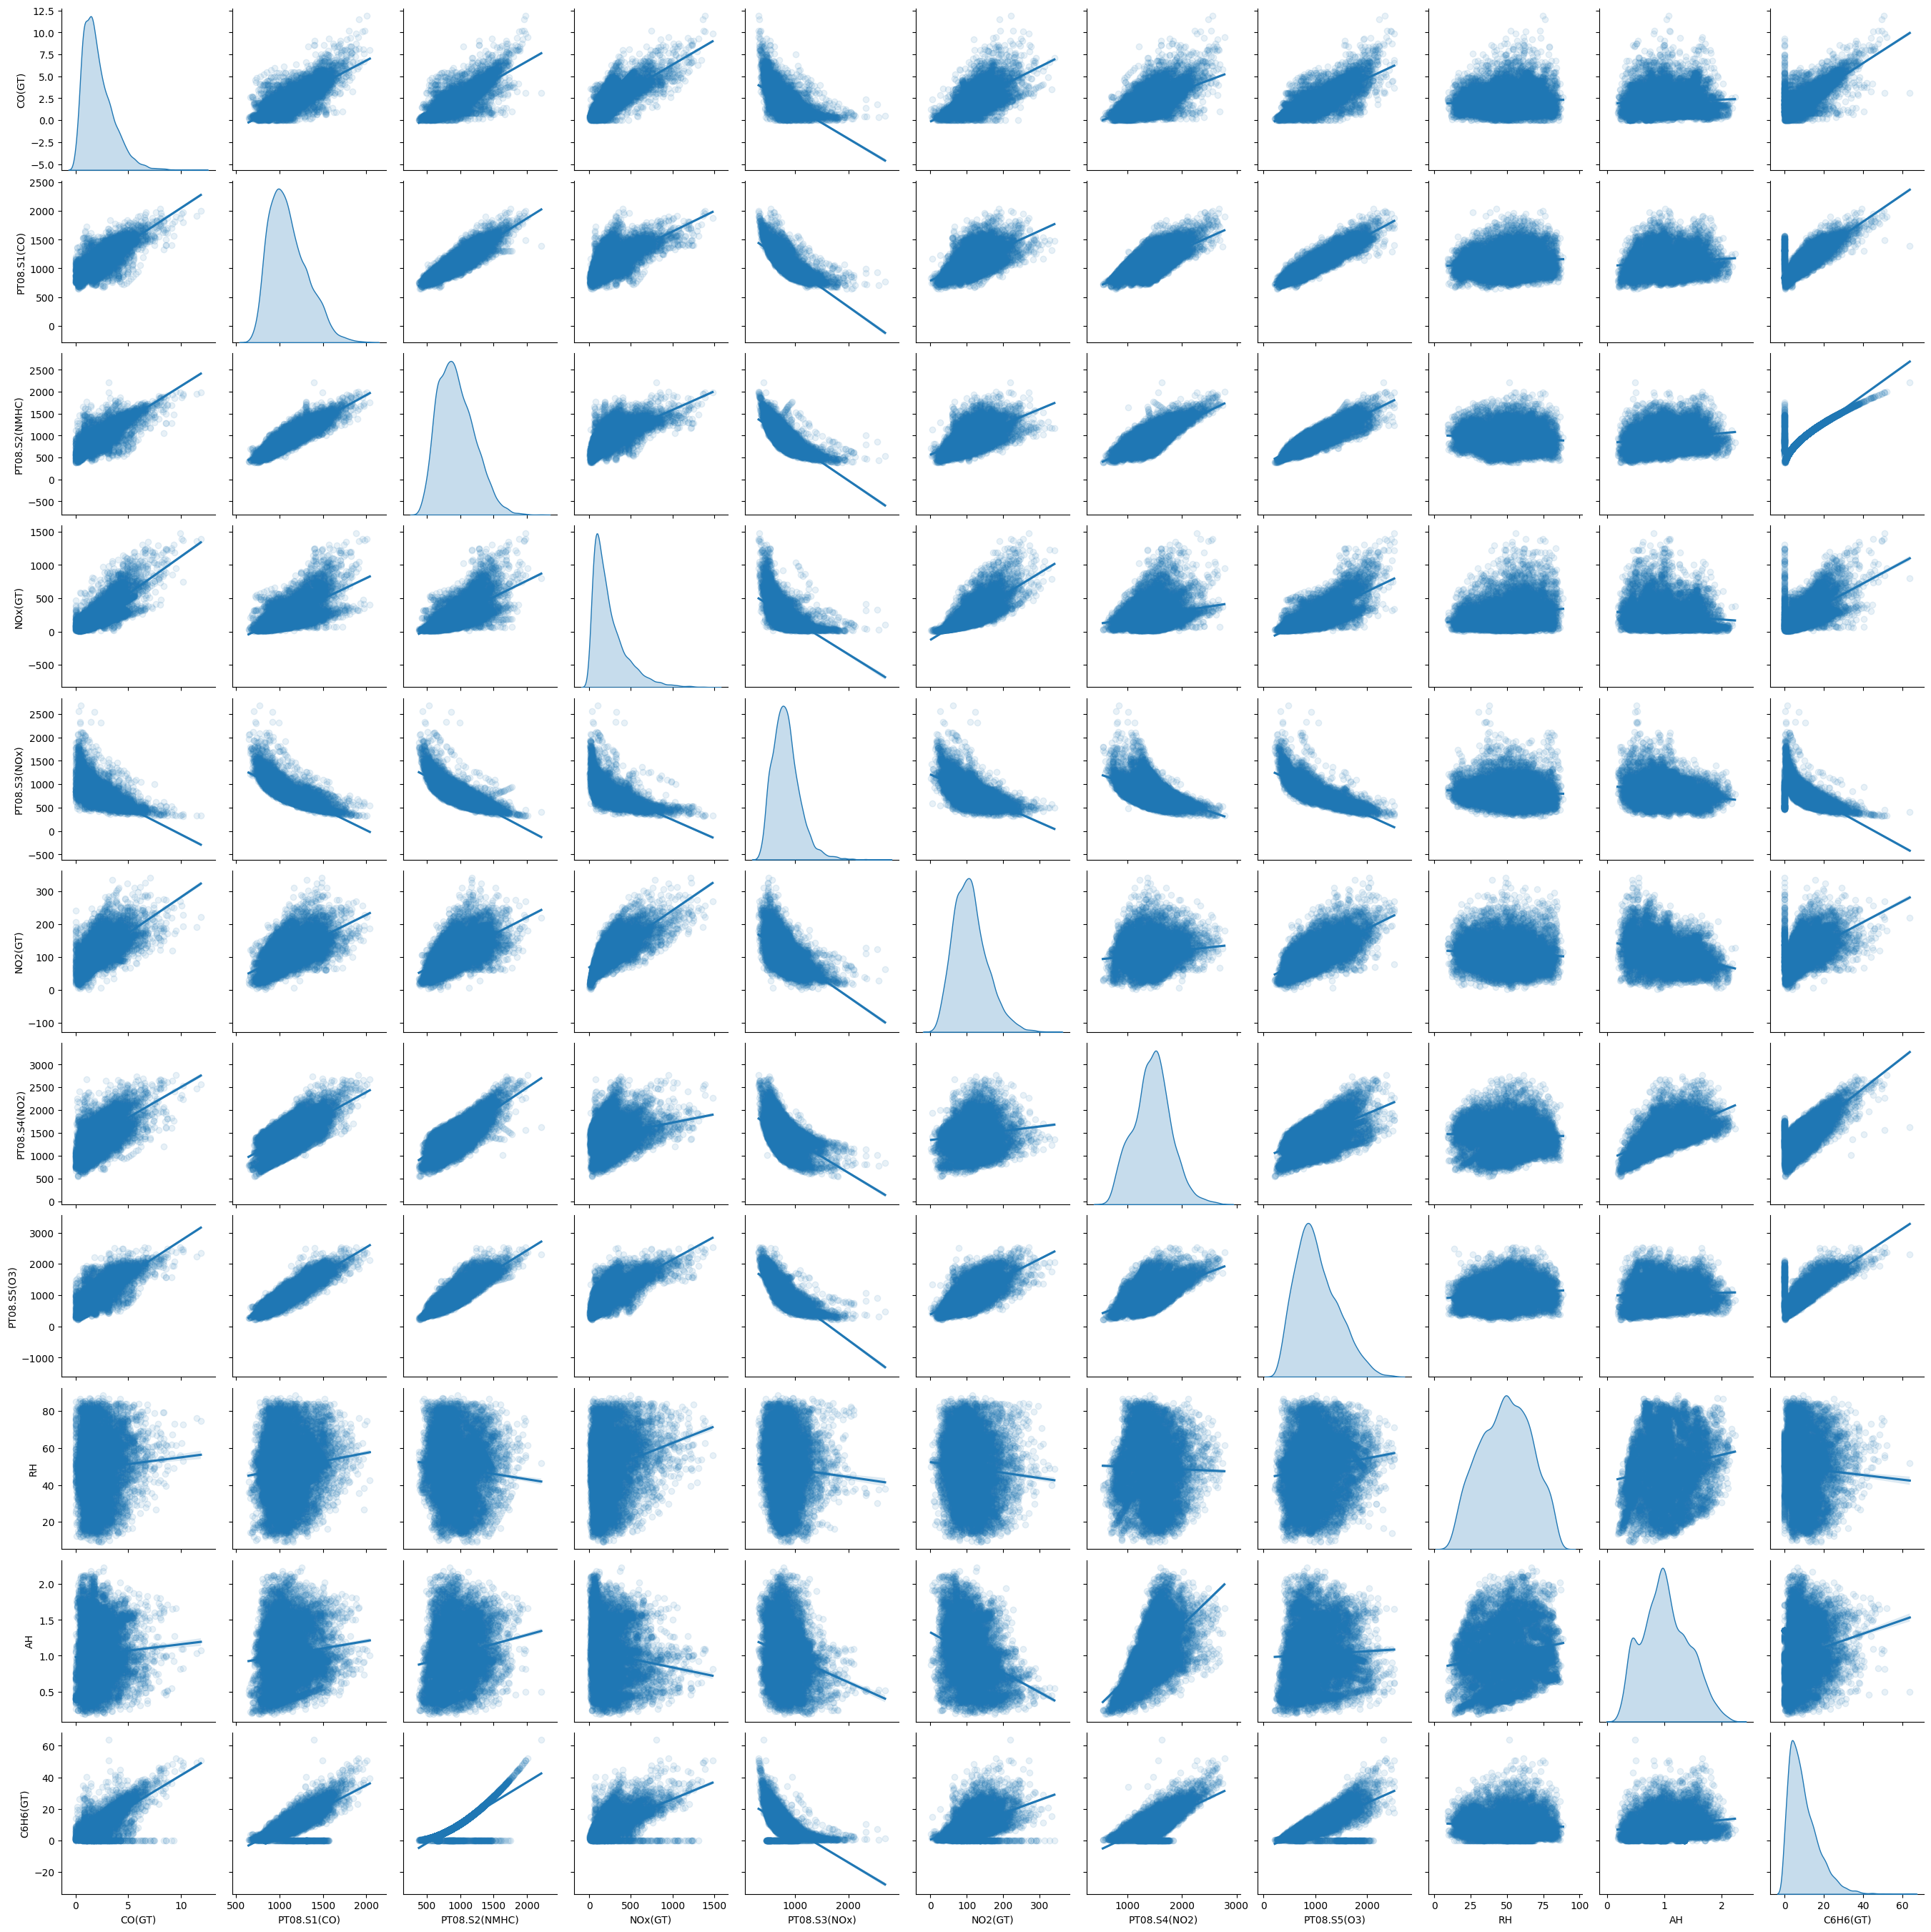

In [7]:
# 상관행렬 시각화
sns.pairplot(
    df, 
    kind='reg', 
    diag_kind='kde', 
    plot_kws={'scatter_kws': {'alpha': 0.1}}
)

In [8]:
# [+] 상관계수 측정
df.corr()

,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH,AH,C6H6(GT)
CO(GT),1.000000,0.793021,0.807142,0.789544,-0.647024,0.673540,0.558919,0.773442,0.061133,0.063548,0.761713
PT08.S1(CO),0.793021,1.000000,0.892045,0.667099,-0.777083,0.617714,0.667361,0.901731,0.115498,0.112241,0.813633
PT08.S2(NMHC),0.807142,0.892045,1.000000,0.646925,-0.793180,0.601650,0.765290,0.875130,-0.089798,0.170344,0.911915
NOx(GT),0.789544,0.667099,0.646925,1.000000,-0.626814,0.763038,0.214655,0.735982,0.212168,-0.122630,0.587481
PT08.S3(NOx),-0.647024,-0.777083,-0.793180,-0.626814,1.000000,-0.622142,-0.528604,-0.798375,-0.062422,-0.212475,-0.685988
NO2(GT),0.673540,0.617714,0.601650,0.763038,-0.622142,1.000000,0.134203,0.679754,-0.077801,-0.322243,0.514042
PT08.S4(NO2),0.558919,0.667361,0.765290,0.214655,-0.528604,0.134203,1.000000,0.569545,-0.026601,0.629481,0.742489
PT08.S5(O3),0.773442,0.901731,0.875130,0.735982,-0.798375,0.679754,0.569545,1.000000,0.127247,0.044611,0.777093
RH,0.061133,0.115498,-0.089798,0.212168,-0.062422,-0.077801,-0.026601,0.127247,1.000000,0.170529,-0.055630
AH,0.063548,0.112241,0.170344,-0.122630,-0.212475,-0.322243,0.629481,0.044611,0.170529,1.000000,0.178522


**모델 학습 및 특징 중요도 출력**

특징 집합을 훈련 데이터로 학습하여 일산화탄소를 예측하는 회귀 모델
- 레이블: 일산화탄소(`CO(GT)`)
- 특징 집합: `CO(GT)`를 제외한 나머지 변수

In [9]:
# [+] 학습 데이터셋 준비
X =  df.iloc[:,1:]# 훈련 데이터
y = df.iloc[:,0]  # 레이블 데이터
print(X.shape, y.shape)

(9357, 10) (9357,)


In [10]:
from sklearn.model_selection import train_test_split

# [+] 훈련 / 테스트 분할
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state =1
)

In [11]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [12]:
# [+] 예측 수행
y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error

# [+] MAE 계산
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE (Mean Absolute Error): {mae:.4f}")

MAE (Mean Absolute Error): 0.2963


In [13]:
from sklearn.metrics import mean_absolute_error 

# [+] MAE 계산 
mae = mean_absolute_error(y_test, y_pred) 
print(f"MAE (Mean Absolute Error): {mae:.4f}")

MAE (Mean Absolute Error): 0.2963


In [14]:
# [+] 특징 중요도 출력
model.feature_importances_

array([0.05581297, 0.538456  , 0.20573671, 0.01808018, 0.04020179,
       0.01919308, 0.01644095, 0.01384966, 0.02349052, 0.06873814])

In [15]:
# 특징 중요도 계산
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances

PT08.S1(CO)      0.055813
PT08.S2(NMHC)    0.538456
NOx(GT)          0.205737
PT08.S3(NOx)     0.018080
NO2(GT)          0.040202
PT08.S4(NO2)     0.019193
PT08.S5(O3)      0.016441
RH               0.013850
AH               0.023491
C6H6(GT)         0.068738
dtype: float64

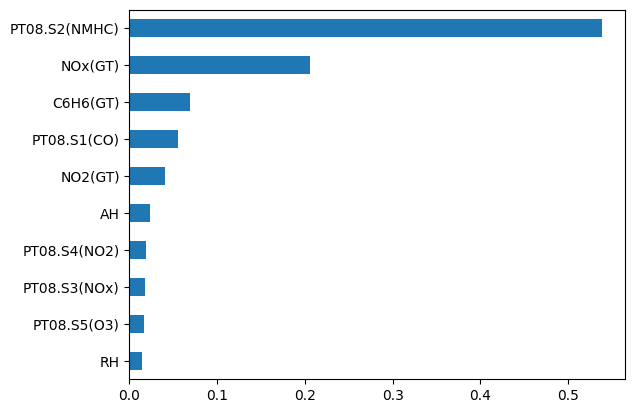

In [16]:
# 특징 중요도 시각화
feat_importances.sort_values(ascending=True).plot(kind='barh')
plt.show()